# OpenRainER - Emilia-Romagna, Italy

Commercial microwave links of the regional network operator Lepida, with the
ARPAE-SIMC radar and rain-gauge network, published by Covi et al.:
[doi:10.5281/zenodo.10593848](https://doi.org/10.5281/zenodo.10593848),
CC BY 4.0. The example subset
([`OpenRainER/`](https://github.com/OpenSenseAction/opensense_example_data/tree/main/OpenRainER))
is 14-21 August 2022:

| sensor | file | content |
|---|---|---|
| CML | `openrainer_cml_8d.nc` | 151 links, 2 sublinks, `tsl` and `rsl` at ~1 min |
| radar | `openrainer_radar_8d.nc` | 15-min accumulations `R` and `R_gauge_adjusted` |
| gauges | `openrainer_gauges_8d.nc` | 319 stations, 15-min accumulations |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import poligrain as plg

from core import viz_style as vs
from core.opensense import example_data, plots

vs.use_style()
C1, C2, C3 = (vs.SERIES[k] for k in vs.SERIES_ORDER)

In [2]:
raw = example_data.load("openrainer", "8d", normalize=False, verbose=False)
data = example_data.load("openrainer", "8d", verbose=False)
cml, radar, gauges = data["cml"], data["radar"], data["gauge"]
cml

<xarray.Dataset> Size: 55MB
Dimensions:        (time: 11412, sublink_id: 2, cml_id: 151)
Coordinates: (12/20)
  * time           (time) datetime64[ns] 91kB 2022-08-14 ... 2022-08-21T23:59:00
  * sublink_id     (sublink_id) <U8 64B 'channel1' 'channel2'
  * cml_id         (cml_id) <U4 2kB '412' '154' '1149' '55' ... '60' '434' '62'
    length         (cml_id) float64 1kB 6.115e+03 2.107e+03 ... 1.037e+03
    site_0_lat     (cml_id) float64 1kB 44.16 44.1 44.71 ... 44.79 44.88 44.82
    site_0_lon     (cml_id) float64 1kB 11.01 11.98 9.623 ... 9.755 11.97 9.738
    ...             ...
    site_0_x       (cml_id) float64 1kB 6.609e+05 7.387e+05 ... 5.583e+05
    site_0_y       (cml_id) float64 1kB 4.892e+06 4.888e+06 ... 4.964e+06
    site_1_x       (cml_id) float64 1kB 6.669e+05 7.404e+05 ... 5.578e+05
    site_1_y       (cml_id) float64 1kB 4.893e+06 4.889e+06 ... 4.965e+06
    x              (cml_id) float64 1kB 6.639e+05 7.396e+05 ... 5.58e+05
    y              (cml_id) float64 1kB 4.892e+06 4.888e+06 ... 4.964e+06
Data variables:
    rsl            (cml_id, sublink_id, time) float64 28MB -36.9 -36.0 ... -48.0
    tsl            (cml_id, sublink_id, time) float64 28MB 17.0 17.0 ... 18.0
Attributes:
    title:              OpenRainER-CML: Lepida ScpA CML received and transmit...
    file_authors:       Elia Covi (ARPAE-SIMC Bologna (IT)); Giacomo Roversi ...
    institution:        Hydro-Meteorological and Climate Service of Emilia-Ro...
    date:               2025-01-01
    source:             Lepida ScpA, Bologna (IT) https://www.lepida.net/ - C...
    naming_convention:  OpenSense-CML
    license:            https://creativecommons.org/licenses/by/4.0/
    contact:            elia.c.covi@gmail.com
    reference:          https://zenodo.org/doi/10.5281/zenodo.10593848
    version:            1.1

## Two traps in the files

**The radar's `R` is not a rate.** It is a 15-minute accumulation in mm; read
as mm/h it is four times too low. `load()` converts it and records how.

**Timestamps name the end of the interval** for the radar and the gauges
(`accumulation_label="end"` in `example_data.DATASETS`). The files do not say
so; it was found by lagging the 1-minute CML signal against each reference.
Any comparison with a start-labelled dataset has to shift by one step.

In [3]:
print("radar as stored :", raw["radar"].R.attrs.get("units"),
      f"  max {float(raw['radar'].R.max()):.1f}")
print("radar normalized:", radar.R.attrs["units"], f"  max {float(radar.R.max()):.1f}",
      f"  ({radar.R.attrs['comment']})")
print("gauge R         :", gauges.R.attrs["comment"])
print("label           :", example_data.DATASETS["openrainer"].accumulation_label)
dt = pd.Series(np.diff(cml.time.values))
gaps = dt[dt > pd.Timedelta("1min")]
print(f"CML time step   : {dt.median()}, {cml.sizes['time']} steps in 8 days (not 11520): "
      f"{len(gaps)} gaps, longest {gaps.max()}")

radar as stored : mm   max 12.2


radar normalized: mm h-1   max 48.6   (converted from 0.25 h accumulation in mm)
gauge R         : rainfall_amount x 4
label           : end
CML time step   : 0 days 00:01:00, 11412 steps in 8 days (not 11520): 1 gaps, longest 0 days 01:49:00


## The network

151 links, 0.2 - 25.2 km, 24.6 - 25.6 GHz


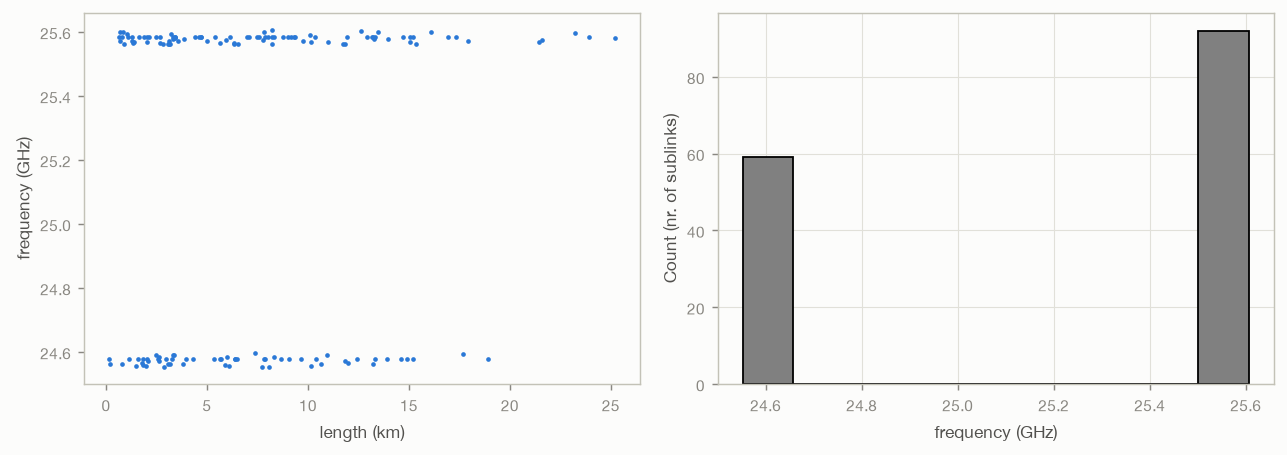

In [4]:
print(f"{cml.sizes['cml_id']} links, {float(cml.length_km.min()):.1f} - "
      f"{float(cml.length_km.max()):.1f} km, "
      f"{float(cml.frequency_ghz.min()):.1f} - {float(cml.frequency_ghz.max()):.1f} GHz")
plots.metadata(cml);

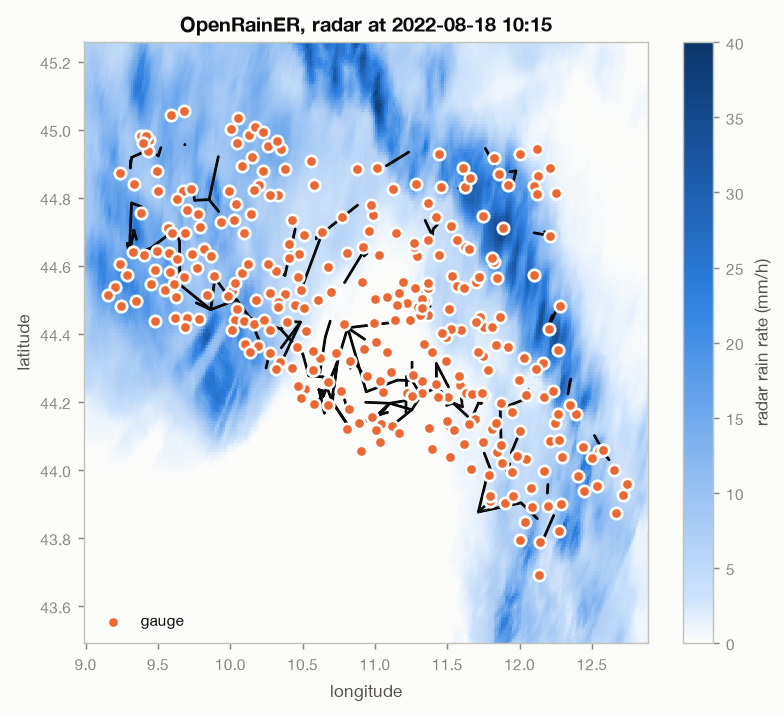

In [5]:
t_peak = radar.R.mean(("y", "x")).idxmax("time").values
fig = plots.network(radar.R.sel(time=t_peak), cml, gauges={"gauge": gauges},
                    title=f"OpenRainER, radar at {pd.Timestamp(t_peak):%Y-%m-%d %H:%M}")
fig.axes[0].set(xlim=(float(cml.site_0_lon.min()) - 0.3, float(cml.site_0_lon.max()) + 0.3),
                ylim=(float(cml.site_0_lat.min()) - 0.3, float(cml.site_0_lat.max()) + 0.3));

## One link through the wettest hours

Total path loss `tsl - rsl` of the link under the most radar rain around the
peak, among links reporting throughout. With the radar averaged along the
path for comparison.

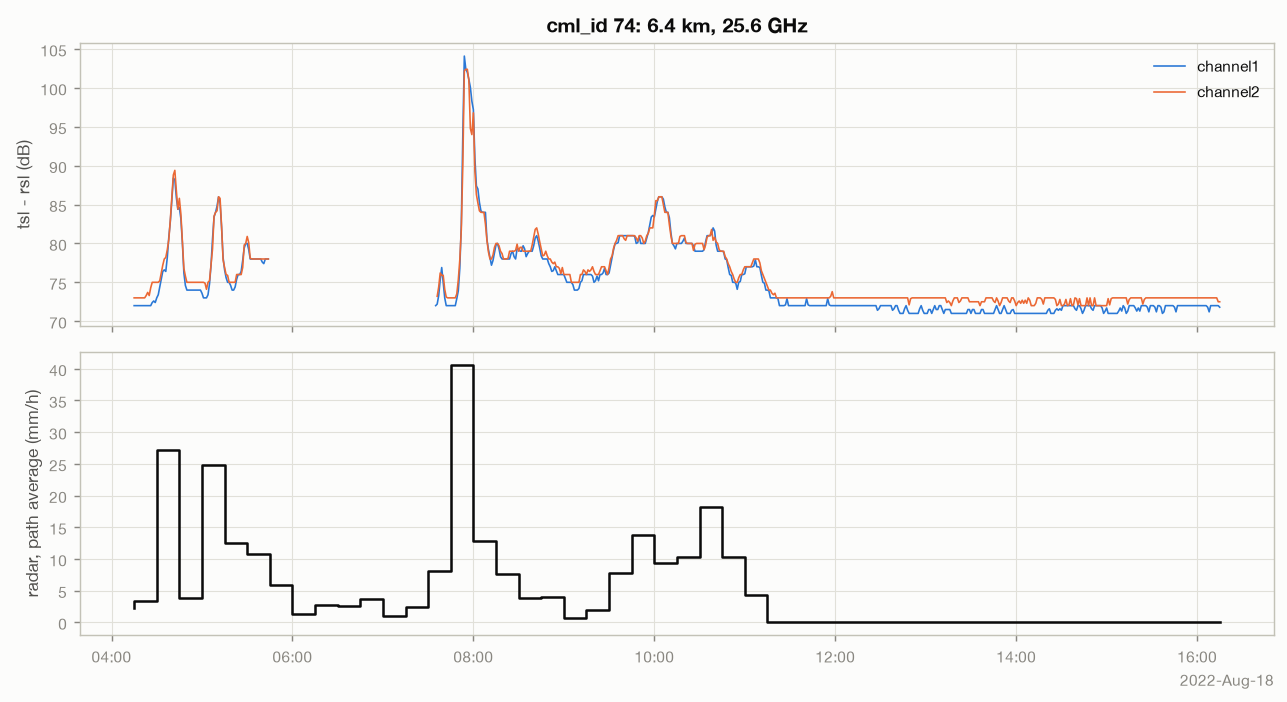

In [6]:
window = slice(pd.Timestamp(t_peak) - pd.Timedelta("6h"), pd.Timestamp(t_peak) + pd.Timedelta("6h"))
tl = (cml.tsl - cml.rsl).sel(time=window)
radar_path = plg.spatial.GridAtLines(radar.R, cml)(radar.R.sel(time=window))
complete = (tl.notnull().mean(("time", "sublink_id")) > 0.95).values
wettest = int(radar_path.sum("time").where(complete).argmax())
link = tl.isel(cml_id=wettest)

fig, axes = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)
for s, c in zip(link.sublink_id.values, (C1, C2)):
    link.sel(sublink_id=s).plot(ax=axes[0], color=c, lw=0.9, label=str(s))
axes[0].set(ylabel="tsl - rsl (dB)", xlabel="",
            title=f"cml_id {link.cml_id.values}: {float(cml.length_km[wettest]):.1f} km, "
                  f"{float(cml.frequency_ghz[wettest].max()):.1f} GHz")
axes[0].legend()
radar_path.isel(cml_id=wettest).plot(ax=axes[1], color=vs.INK_PRIMARY, lw=1.4, drawstyle="steps-pre")
axes[1].set(ylabel="radar, path average (mm/h)", xlabel="", title="")
fig.tight_layout()

## Radar against gauges

Same 15-minute steps, same end-of-interval labels, so they compare directly.
Radar pixel above each gauge, raw and gauge-adjusted.

radar                  r=0.71  total/gauge=1.34
radar, gauge-adjusted  r=0.90  total/gauge=1.00


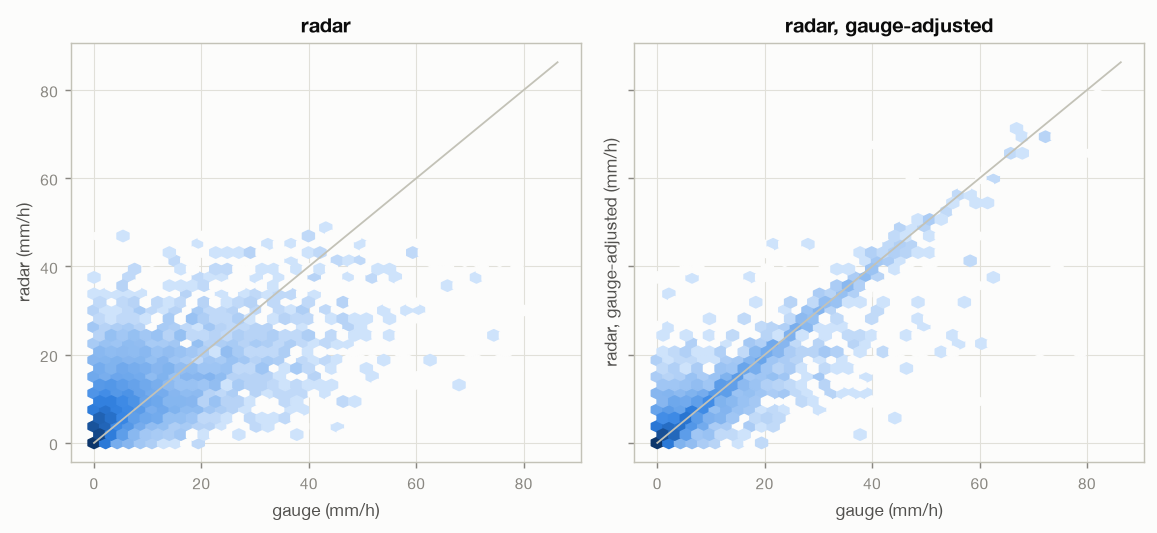

In [7]:
pick = plg.spatial.GridAtPoints(radar.R, gauges.R, nnear=1)
adj = (radar.R_gauge_adjusted / 0.25).assign_attrs(units="mm h-1")
frame = pd.DataFrame({
    "gauge": gauges.R.transpose("time", "id").values.ravel(),
    "radar": pick(radar.R, gauges.R).transpose("time", "id").values.ravel(),
    "radar, gauge-adjusted": pick(adj, gauges.R).transpose("time", "id").values.ravel(),
}).dropna()
wet = frame[frame.max(axis=1) > 0.1]
for col in ("radar", "radar, gauge-adjusted"):
    print(f"{col:22s} r={wet.gauge.corr(wet[col]):.2f}  total/gauge={wet[col].sum() / wet.gauge.sum():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(9, 4.2), sharex=True, sharey=True)
lim = float(wet.quantile(0.999).max())
for ax, col in zip(axes, ("radar", "radar, gauge-adjusted")):
    ax.hexbin(wet.gauge, wet[col], gridsize=40, bins="log", extent=(0, lim, 0, lim), cmap=vs.CMAP_RAIN)
    ax.plot([0, lim], [0, lim], color=vs.BASELINE, lw=1)
    ax.set(xlabel="gauge (mm/h)", ylabel=f"{col} (mm/h)", title=col)
fig.tight_layout()